# quick_test.ipynb — end-to-end pipeline check

Runs the WHOLE pipeline in miniature:

1. **Load** a tiny subset of one BOLD file.
2. **Train** the 3D U-Net for 1 epoch on a handful of triplets.
3. **Save** a checkpoint.
4. **Inference** — reload the weights and predict a held-out frame.
5. **Visualize** prediction vs ground truth + brain-overlay error heatmap.
6. **Generate data** — run inference over several consecutive pairs and write a new NIfTI to `results/quick_test/`.

Smoke test only — 1 epoch on ~8 triplets is not meaningful training.

In [6]:
# Make the project root importable when running from notebooks/.
import sys
from pathlib import Path
PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))
print('project root:', PROJECT_ROOT)

project root: /home/özkan/CAI-MedImg/data_interpolation


In [7]:
import numpy as np
import torch
import nibabel as nib
from torch.utils.data import DataLoader, Subset
from scipy.ndimage import gaussian_filter

from src.dataset import FMRIInterpolationDataset
from src.model import UNet3D
from src.loss import HybridL1SSIMLoss
from src.utils import pick_device, seed_everything

seed_everything(0)
device = pick_device()
print('device:', device)

device: cuda


In [8]:
# # === STEP 1: locate a BOLD file ===
# # Drop a *_bold.nii.gz into data_interpolation/data/ — the first hit is used.
# candidates = sorted((PROJECT_ROOT / 'fMRI-data').rglob('*_bold.nii.gz'))
# if not candidates:
#     raise FileNotFoundError(
#         'No *_bold.nii.gz found under data/. Drop a BOLD file there or '
#         'set BOLD_FILE manually below.'
#     )
# BOLD_FILE = str(candidates[0])
# print('using:', BOLD_FILE)

from pathlib import Path

# === STEP 1: locate a BOLD file ===
DATA_ROOT = Path("/srv/fMRI-data")

candidates = sorted(DATA_ROOT.rglob("*_bold.nii.gz"))
if not candidates:
    raise FileNotFoundError(
        f"No *_bold.nii.gz found under {DATA_ROOT}. "
        "Check the dataset path or set BOLD_FILE manually."
    )

BOLD_FILE = str(candidates[0])
print("using:", BOLD_FILE)

using: /srv/fMRI-data/sub-01_ses-03_task-HcpLanguage_dir-ap_bold.nii.gz


In [9]:
# === STEP 2: dataset + tiny train/val split ===
full = FMRIInterpolationDataset(file_list=[BOLD_FILE], norm_mode='zscore')
print('full triplets:', len(full))

N_TRAIN = min(8, len(full) - 4)
train_indices = list(range(2, 2 + N_TRAIN))
val_indices = list(range(2 + N_TRAIN, 2 + N_TRAIN + 2))
train_set = Subset(full, train_indices)
val_set = Subset(full, val_indices) if val_indices[-1] < len(full) else None
print('train:', len(train_set), 'val:', len(val_set) if val_set else 0)

train_loader = DataLoader(train_set, batch_size=1, shuffle=True)
val_loader = DataLoader(val_set, batch_size=1) if val_set else None

full triplets: 217
train: 8 val: 2


In [10]:
# === STEP 3: train 1 epoch (smoke test) ===
model = UNet3D(in_channels=2, out_channels=1, base_channels=32, depth=4).to(device)
criterion = HybridL1SSIMLoss(alpha=0.5, data_range=2.0).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-5)

model.train()
for step, batch in enumerate(train_loader, start=1):
    x = batch['x'].to(device)
    y = batch['y'].to(device)
    pred = model(x)
    loss, comps = criterion(pred, y, return_components=True)
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()
    print(f'  step {step}/{len(train_loader)}  loss={loss.item():.4f}  l1={comps["l1"].item():.4f}  ssim={comps["ssim"].item():.4f}')

if val_loader is not None:
    model.eval()
    val_losses = []
    with torch.no_grad():
        for batch in val_loader:
            x = batch['x'].to(device); y = batch['y'].to(device)
            val_losses.append(criterion(model(x), y).item())
    print(f'val_loss = {np.mean(val_losses):.4f}')

  step 1/8  loss=0.8733  l1=0.8229  ssim=0.0764
  step 2/8  loss=0.6649  l1=0.5350  ssim=0.2053
  step 3/8  loss=0.5491  l1=0.4045  ssim=0.3063
  step 4/8  loss=0.4591  l1=0.3196  ssim=0.4013
  step 5/8  loss=0.4103  l1=0.2792  ssim=0.4587
  step 6/8  loss=0.3754  l1=0.2515  ssim=0.5008
  step 7/8  loss=0.3414  l1=0.2329  ssim=0.5501
  step 8/8  loss=0.3151  l1=0.2206  ssim=0.5903
val_loss = 0.2871


In [11]:
# === STEP 4: save the trained weights ===
ckpt_dir = PROJECT_ROOT / 'checkpoints' / 'quick_test'
ckpt_dir.mkdir(parents=True, exist_ok=True)
torch.save(model.state_dict(), ckpt_dir / 'model_weights.pt')
print('wrote', ckpt_dir / 'model_weights.pt')

wrote /home/özkan/CAI-MedImg/data_interpolation/checkpoints/quick_test/model_weights.pt


In [12]:
# === STEP 5: reload weights and run inference on a held-out triplet ===
fresh = UNet3D(in_channels=2, out_channels=1, base_channels=32, depth=4).to(device)
fresh.load_state_dict(torch.load(ckpt_dir / 'model_weights.pt', map_location=device))
fresh.eval()

TEST_IDX = val_indices[0] if val_set else 0
sample = full[TEST_IDX]
x = sample['x'].unsqueeze(0).to(device)
y = sample['y'].unsqueeze(0).to(device)
with torch.no_grad():
    pred = fresh(x)
    naive = 0.5 * (x[:, 0:1] + x[:, 1:2])
    l1_model = (pred - y).abs().mean().item()
    l1_naive = (naive - y).abs().mean().item()
print(f'held-out t={sample["t"]}  model L1 = {l1_model:.4f}  naive L1 = {l1_naive:.4f}')
print('(1 epoch on ~8 samples — model often loses to naive here. The point is that the pipeline runs.)')

held-out t=10  model L1 = 0.1994  naive L1 = 0.0587
(1 epoch on ~8 samples — model often loses to naive here. The point is that the pipeline runs.)


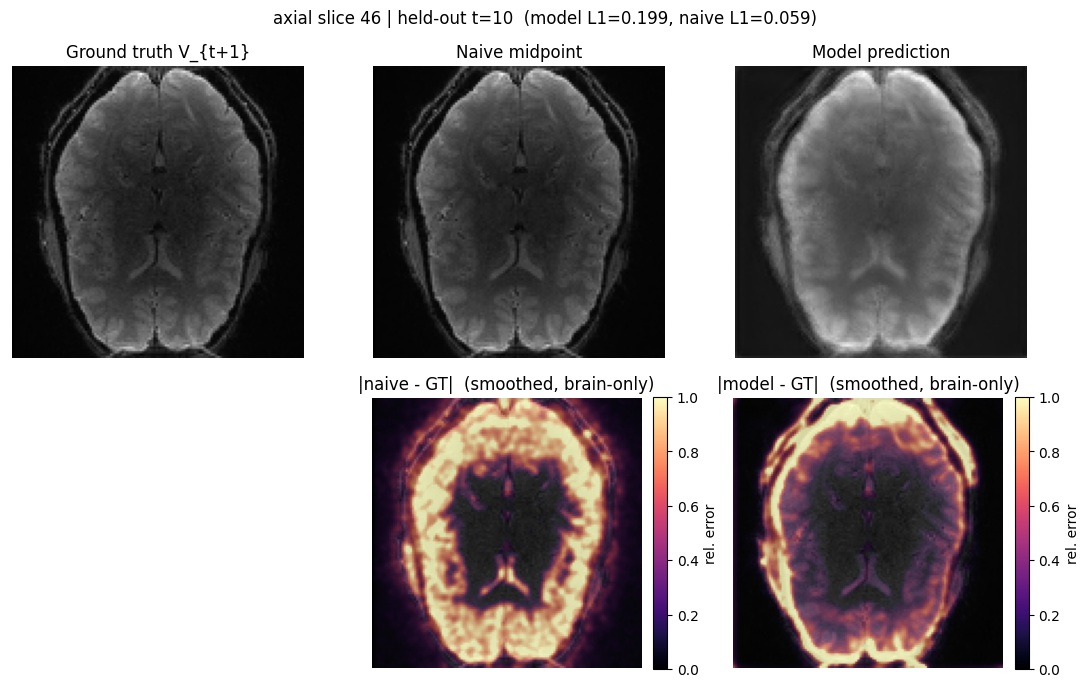

In [13]:
# === STEP 6: GT vs model pred + brain-overlay error heatmap ===
# Same visualization style as the demo3 notebook: errors are masked to the
# brain, lightly Gaussian-smoothed, percentile-clipped, and alpha-blended
# over the ground-truth slice so anatomical location stays visible.
import matplotlib.pyplot as plt

v_gt    = y[0, 0].cpu().numpy()         # (D, H, W) — ground-truth V_{t+1}
v_pred  = pred[0, 0].cpu().numpy()
v_naive = naive[0, 0].cpu().numpy()

# Build a brain-ish mask from the GT volume so error overlays ignore air/skull.
mask_source = np.abs(v_gt)
brain_mask  = mask_source > np.percentile(mask_source, 20)

def error_overlay(true_vol, pred_vol, mask, sigma=1.2, pct=95):
    """Return brain-masked, smoothed, percentile-clipped |true - pred| in [0, 1]."""
    err = np.abs(true_vol - pred_vol)
    err = err * mask                                # zero-out non-brain
    err = gaussian_filter(err, sigma=sigma)         # merge per-voxel noise
    if err[mask].size:
        clip = np.percentile(err[mask], pct)
    else:
        clip = err.max() or 1.0
    if clip <= 0:
        clip = 1.0
    return np.clip(err / clip, 0.0, 1.0)

err_model = error_overlay(v_gt, v_pred,  brain_mask)
err_naive = error_overlay(v_gt, v_naive, brain_mask)

slice_idx = v_gt.shape[0] // 2  # middle axial slice
fig, axes = plt.subplots(2, 3, figsize=(11, 7))

# Top row: GT, naive midpoint, model prediction.
for ax, vol, title in zip(
    axes[0],
    [v_gt, v_naive, v_pred],
    ['Ground truth V_{t+1}', 'Naive midpoint', 'Model prediction']
):
    ax.imshow(vol[slice_idx], cmap='gray')
    ax.set_title(title); ax.axis('off')

# Bottom row: brain underlay + error overlay (alpha proportional to error).
axes[1, 0].axis('off')
for ax, err, title in zip(
    axes[1, 1:],
    [err_naive, err_model],
    ['|naive - GT|  (smoothed, brain-only)', '|model - GT|  (smoothed, brain-only)']
):
    ax.imshow(v_gt[slice_idx], cmap='gray')
    im = ax.imshow(err[slice_idx], cmap='magma', alpha=err[slice_idx] * 0.85, vmin=0, vmax=1)
    ax.set_title(title); ax.axis('off')
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='rel. error')

fig.suptitle(f'axial slice {slice_idx} | held-out t={sample["t"]}  '
             f'(model L1={l1_model:.3f}, naive L1={l1_naive:.3f})')
fig.tight_layout()
plt.show()

## STEP 7 — generate new data and save it

Run inference over several consecutive frame-pairs of the BOLD file and save
the interpolated frames as a new 4D NIfTI. This is the same logic `main.py`
uses, scoped to a few frames so it stays fast inside the notebook.

Output goes to `results/quick_test/generated.nii.gz`.

In [14]:
def normalize_pair_zscore(v_a, v_b):
    """Per-pair z-score normalization using only input voxels (matches dataset)."""
    src = np.abs(v_a) + np.abs(v_b)
    mask = src > np.percentile(src, 20)
    pool = np.concatenate([v_a[mask], v_b[mask]]) if int(mask.sum()) >= 100 \
           else np.concatenate([v_a.ravel(), v_b.ravel()])
    mu = float(pool.mean())
    sigma = float(max(pool.std(), 1e-6))
    return (v_a - mu) / sigma, (v_b - mu) / sigma, mu, sigma

img = nib.load(BOLD_FILE)
T = int(img.shape[-1])
# Use a short window so the notebook stays quick.
T_START = 2
T_END   = min(T_START + 8, T)              # 8 frames -> 7 inserted frames -> 15 output frames
n_in    = T_END - T_START
out_T   = 2 * n_in - 1
print(f'generating from frames {T_START}..{T_END - 1}  →  {out_T} output frames')

spatial = img.shape[:3]
out_arr = np.empty(spatial + (out_T,), dtype=np.float32)

# Copy originals into even slots.
for i, t in enumerate(range(T_START, T_END)):
    out_arr[..., 2 * i] = np.asarray(img.dataobj[..., t], dtype=np.float32)

# Predict the midpoint for each consecutive pair.
fresh.eval()
with torch.no_grad():
    for i in range(n_in - 1):
        v_a = np.asarray(img.dataobj[..., T_START + i], dtype=np.float32)
        v_b = np.asarray(img.dataobj[..., T_START + i + 1], dtype=np.float32)
        a_n, b_n, mu, sigma = normalize_pair_zscore(v_a, v_b)
        a_t = torch.from_numpy(np.ascontiguousarray(a_n.transpose(2, 1, 0))).float()
        b_t = torch.from_numpy(np.ascontiguousarray(b_n.transpose(2, 1, 0))).float()
        x_in = torch.stack([a_t, b_t], dim=0).unsqueeze(0).to(device)
        mid_norm = fresh(x_in).squeeze(0).squeeze(0).cpu().numpy()
        mid = mid_norm * sigma + mu                                  # denormalize
        out_arr[..., 2 * i + 1] = np.ascontiguousarray(mid.transpose(2, 1, 0))

# Halve TR in the header to reflect doubled temporal resolution.
new_header = img.header.copy()
try:
    pixdim = new_header['pixdim'].copy()
    if pixdim[4] > 0:
        pixdim[4] = pixdim[4] / 2.0
        new_header['pixdim'] = pixdim
except Exception:
    pass

out_dir = PROJECT_ROOT / 'results' / 'quick_test'
out_dir.mkdir(parents=True, exist_ok=True)
out_path = out_dir / 'generated.nii.gz'
nib.save(nib.Nifti1Image(out_arr, affine=img.affine, header=new_header), str(out_path))
print(f'wrote {out_path}')
print(f'  input  shape (cropped): {spatial + (n_in,)}')
print(f'  output shape          : {out_arr.shape}')

generating from frames 2..9  →  15 output frames
wrote /home/özkan/CAI-MedImg/data_interpolation/results/quick_test/generated.nii.gz
  input  shape (cropped): (128, 128, 93, 8)
  output shape          : (128, 128, 93, 15)


on-disk shape : (128, 128, 93, 15)
on-disk dtype : float32


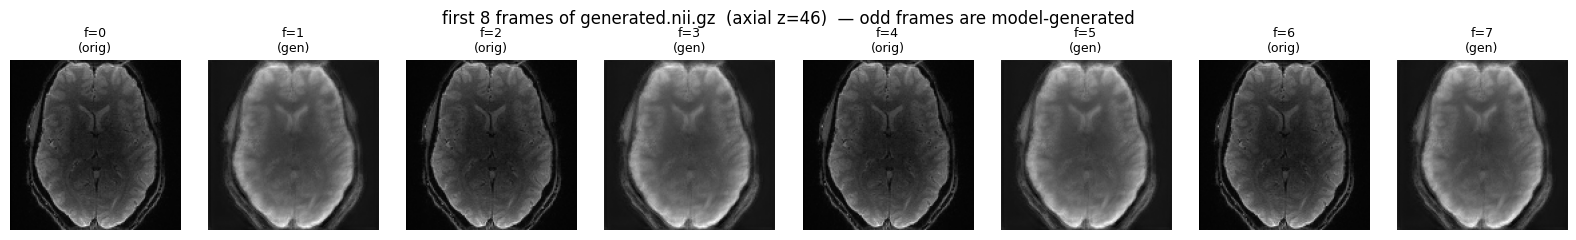

In [15]:
# === verify: read the file back and show a strip of frames ===
reread = nib.load(str(out_path))
print('on-disk shape :', reread.shape)
print('on-disk dtype :', reread.get_data_dtype())

arr = np.asarray(reread.dataobj)
n_show = min(8, arr.shape[-1])
z = arr.shape[2] // 2
fig, axes = plt.subplots(1, n_show, figsize=(2 * n_show, 2.4))
for k, ax in enumerate(axes):
    ax.imshow(arr[:, :, z, k].T, cmap='gray', origin='lower')
    tag = 'orig' if k % 2 == 0 else 'gen'
    ax.set_title(f'f={k}\n({tag})', fontsize=9); ax.axis('off')
fig.suptitle(f'first {n_show} frames of generated.nii.gz  (axial z={z})  '
             f'— odd frames are model-generated')
fig.tight_layout()
plt.show()

## ✅ Pipeline verified

- Trained for 1 epoch and saved a checkpoint.
- Reloaded the weights and produced a held-out prediction.
- Plotted brain-overlay error heatmaps showing where the model differs from
  ground truth.
- **Generated and saved** a new NIfTI at `results/quick_test/generated.nii.gz`
  with originals at even indices and model-predicted frames at odd indices.

### Real training & inference
```bash
python train.py --config configs/default.yaml

python main.py \
    --weights checkpoints/pretrained/model_weights.pt \
    --input  data/your_bold.nii.gz \
    --output results/your_bold_2x.nii.gz
```